In [1]:
# Mount Google Drive
from google.colab import drive

drive.mount('/content/drive')


Mounted at /content/drive


## Unzip Dataset


In [2]:
from pathlib import Path
import zipfile
import shutil

ZIP_PATH = Path("/content/drive/MyDrive/CASIA_246.zip")
EXTRACT_DIR = Path("/content/datasets")

DATASET_DIR = EXTRACT_DIR / "CASIA_246"
TRAIN_DIR = DATASET_DIR / "train"
TEST_DIR = DATASET_DIR / "test"

# Remove the previously extracted dataset
if DATASET_DIR.exists():
    shutil.rmtree(DATASET_DIR)

EXTRACT_DIR.mkdir(parents=True, exist_ok=True)

def fix_zip_filename(filename):
    # Fix filenames that were stored as UTF-8 but read as cp437
    try:
        return filename.encode("cp437").decode("utf-8")
    except UnicodeDecodeError:
        return filename

with zipfile.ZipFile(ZIP_PATH, "r") as zip_ref:
    for file_info in zip_ref.infolist():
        fixed_name = fix_zip_filename(file_info.filename)
        target_path = EXTRACT_DIR / fixed_name

        if file_info.is_dir():
            target_path.mkdir(parents=True, exist_ok=True)
        else:
            target_path.parent.mkdir(parents=True, exist_ok=True)

            with zip_ref.open(file_info) as source:
                with open(target_path, "wb") as target:
                    target.write(source.read())

print("Dataset extracted.")


Dataset extracted.


## Verify Dataset Structure


In [3]:
# Check the required dataset folders
assert TRAIN_DIR.exists(), f"Missing train folder: {TRAIN_DIR}"
assert TEST_DIR.exists(), f"Missing test folder: {TEST_DIR}"

train_classes = sorted([folder.name for folder in TRAIN_DIR.iterdir() if folder.is_dir()])
test_classes = sorted([folder.name for folder in TEST_DIR.iterdir() if folder.is_dir()])

print("Train folder:", TRAIN_DIR)
print("Test folder:", TEST_DIR)

print("Number of train classes:", len(train_classes))
print("Number of test classes:", len(test_classes))

print("First 10 classes:")
print(train_classes[:10])

# Make sure train and test folders contain the same classes
assert train_classes == test_classes, "Train and test classes do not match."

print("Dataset structure is correct.")


Train folder: /content/datasets/CASIA_246/train
Test folder: /content/datasets/CASIA_246/test
Number of train classes: 246
Number of test classes: 246
First 10 classes:
['一', '七', '三', '上', '下', '不', '东', '两', '个', '中']
Dataset structure is correct.


## Count Classes and Images


In [4]:
IMAGE_EXTENSIONS = {".png", ".jpg", ".jpeg", ".bmp"}

def count_images_by_class(directory):
    class_counts = {}

    for class_folder in sorted(directory.iterdir()):
        if class_folder.is_dir():
            images = [
                file for file in class_folder.iterdir()
                if file.suffix.lower() in IMAGE_EXTENSIONS
            ]
            class_counts[class_folder.name] = len(images)

    total_images = sum(class_counts.values())
    return class_counts, total_images

train_counts, train_total = count_images_by_class(TRAIN_DIR)
test_counts, test_total = count_images_by_class(TEST_DIR)

print("Number of classes:", len(train_counts))
print("Training images:", train_total)
print("Test images:", test_total)
print("Total images:", train_total + test_total)

print("\nSample class counts:")
for class_name in list(train_counts.keys())[:10]:
    print(f"{class_name}: {train_counts[class_name]} train, {test_counts[class_name]} test")


Number of classes: 246
Training images: 147265
Test images: 35108
Total images: 182373

Sample class counts:
一: 599 train, 142 test
七: 600 train, 140 test
三: 596 train, 144 test
上: 597 train, 144 test
下: 601 train, 143 test
不: 603 train, 142 test
东: 601 train, 142 test
两: 598 train, 141 test
个: 602 train, 142 test
中: 596 train, 143 test


## Display Random Samples


In [5]:
# Install a font that supports Chinese characters
!apt-get -qq install fonts-noto-cjk


Selecting previously unselected package fonts-noto-cjk.
(Reading database ... 122412 files and directories currently installed.)
Preparing to unpack .../fonts-noto-cjk_1%3a20220127+repack1-1_all.deb ...
Unpacking fonts-noto-cjk (1:20220127+repack1-1) ...
Setting up fonts-noto-cjk (1:20220127+repack1-1) ...
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...


In [6]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# Use Noto Sans CJK for Chinese labels in plots
font_path = "/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc"
chinese_font = fm.FontProperties(fname=font_path)

plt.rcParams["axes.unicode_minus"] = False


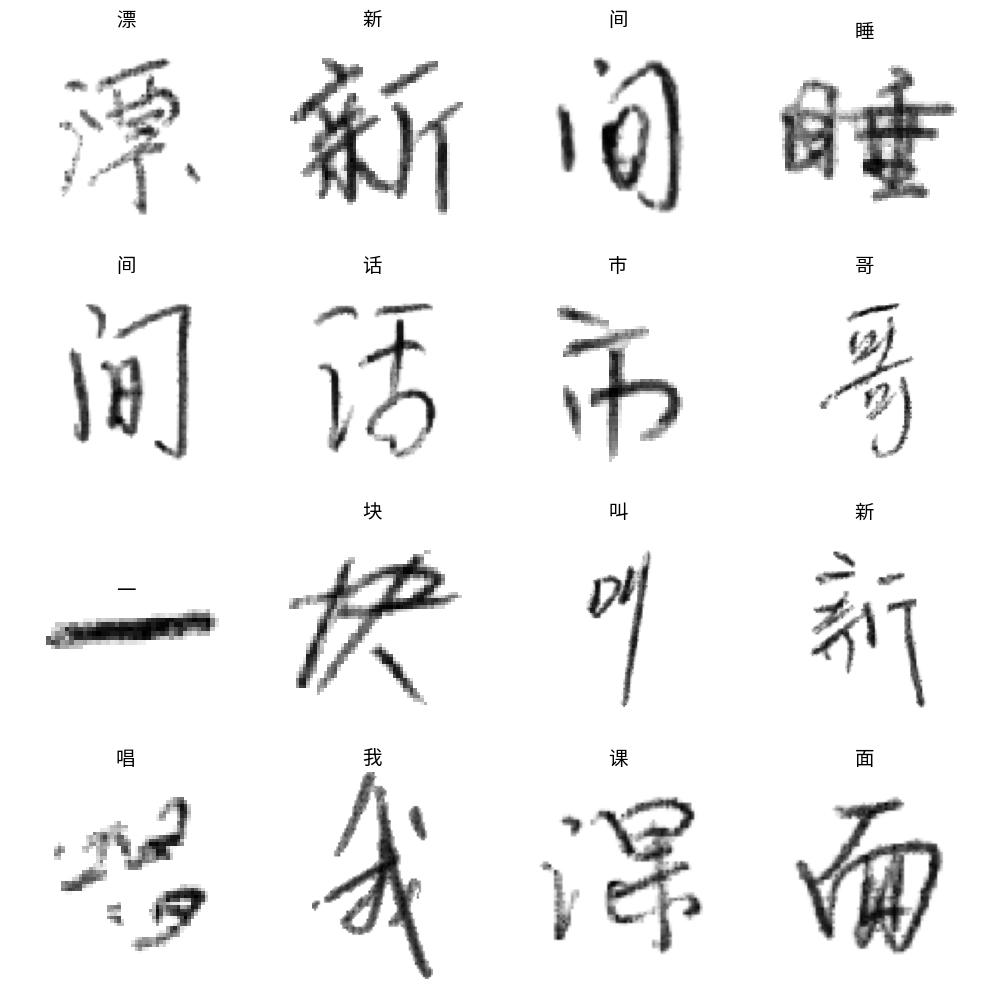

In [7]:
import random
import matplotlib.pyplot as plt
from PIL import Image

def collect_image_paths(directory):
    image_paths = []

    for class_folder in directory.iterdir():
        if class_folder.is_dir():
            for image_path in class_folder.iterdir():
                if image_path.suffix.lower() in IMAGE_EXTENSIONS:
                    image_paths.append((image_path, class_folder.name))

    return image_paths

train_image_paths = collect_image_paths(TRAIN_DIR)
samples = random.sample(train_image_paths, 16)

plt.figure(figsize=(10, 10))

for index, (image_path, label) in enumerate(samples):
    image = Image.open(image_path).convert("L")

    plt.subplot(4, 4, index + 1)
    plt.imshow(image, cmap="gray")
    plt.title(label, fontproperties=chinese_font, fontsize=14)
    plt.axis("off")

plt.tight_layout()
plt.show()


## Check Class Balance


Train images per class:
Minimum: 585
Maximum: 604
Mean: 598.64
Standard deviation: 2.71

Test images per class:
Minimum: 136
Maximum: 146
Mean: 142.72
Standard deviation: 1.26


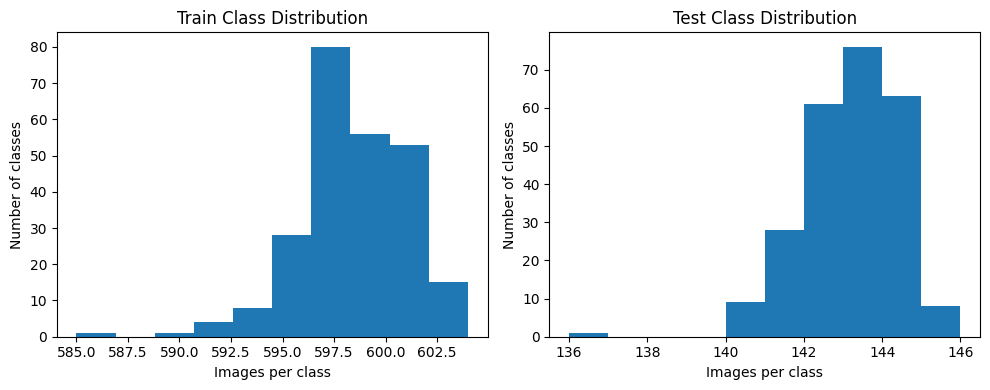

In [8]:
import numpy as np

train_values = list(train_counts.values())
test_values = list(test_counts.values())

print("Train images per class:")
print("Minimum:", min(train_values))
print("Maximum:", max(train_values))
print("Mean:", round(np.mean(train_values), 2))
print("Standard deviation:", round(np.std(train_values), 2))

print("\nTest images per class:")
print("Minimum:", min(test_values))
print("Maximum:", max(test_values))
print("Mean:", round(np.mean(test_values), 2))
print("Standard deviation:", round(np.std(test_values), 2))

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.hist(train_values, bins=10)
plt.title("Train Class Distribution")
plt.xlabel("Images per class")
plt.ylabel("Number of classes")

plt.subplot(1, 2, 2)
plt.hist(test_values, bins=10)
plt.title("Test Class Distribution")
plt.xlabel("Images per class")
plt.ylabel("Number of classes")

plt.tight_layout()
plt.show()


## Image Preprocessing


In [9]:
import torch
from torchvision import datasets, transforms

IMAGE_SIZE = 64

# Transformations for training images
train_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),

    # Light augmentation is used to keep character shapes readable
    transforms.RandomRotation(
        degrees=5,
        fill=255
    ),
    transforms.RandomAffine(
        degrees=0,
        translate=(0.04, 0.04),
        scale=(0.95, 1.05),
        shear=3,
        fill=255
    ),

    transforms.ToTensor(),
    transforms.Normalize(mean=(0.5,), std=(0.5,))
])

# Transformations for validation and test images
test_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.5,), std=(0.5,))
])


## Create PyTorch Datasets


In [10]:
# Augmented dataset is used for training folds
train_dataset_augmented = datasets.ImageFolder(
    root=TRAIN_DIR,
    transform=train_transform
)

# Plain dataset is used for validation folds
train_dataset_plain = datasets.ImageFolder(
    root=TRAIN_DIR,
    transform=test_transform
)

# Test dataset is kept only for final evaluation
test_dataset = datasets.ImageFolder(
    root=TEST_DIR,
    transform=test_transform
)

print("Training folder samples:", len(train_dataset_augmented))
print("Test folder samples:", len(test_dataset))
print("Number of classes:", len(train_dataset_augmented.classes))

print("\nFirst 10 class indices:")
for class_name, class_index in list(train_dataset_augmented.class_to_idx.items())[:10]:
    print(f"{class_name}: {class_index}")


Training folder samples: 147265
Test folder samples: 35108
Number of classes: 246

First 10 class indices:
一: 0
七: 1
三: 2
上: 3
下: 4
不: 5
东: 6
两: 7
个: 8
中: 9


## Create 5-Fold Cross-Validation Split


In [11]:
from sklearn.model_selection import StratifiedKFold

K_FOLDS = 5
RANDOM_STATE = 42

# Labels are needed to keep class proportions similar in each fold
targets = train_dataset_augmented.targets

skf = StratifiedKFold(
    n_splits=K_FOLDS,
    shuffle=True,
    random_state=RANDOM_STATE
)

folds = list(skf.split(range(len(targets)), targets))

print("Number of folds:", len(folds))

for fold_index, (train_indices, validation_indices) in enumerate(folds):
    print(
        f"Fold {fold_index + 1}: "
        f"train = {len(train_indices)}, "
        f"validation = {len(validation_indices)}"
    )


Number of folds: 5
Fold 1: train = 117812, validation = 29453
Fold 2: train = 117812, validation = 29453
Fold 3: train = 117812, validation = 29453
Fold 4: train = 117812, validation = 29453
Fold 5: train = 117812, validation = 29453


## Create DataLoaders for One Fold


In [12]:
from torch.utils.data import DataLoader, Subset

BATCH_SIZE = 64
FOLD_INDEX = 0

train_indices, validation_indices = folds[FOLD_INDEX]

fold_train_dataset = Subset(train_dataset_augmented, train_indices)
fold_validation_dataset = Subset(train_dataset_plain, validation_indices)

fold_train_loader = DataLoader(
    fold_train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

fold_validation_loader = DataLoader(
    fold_validation_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("Current fold:", FOLD_INDEX + 1)
print("Training samples:", len(fold_train_dataset))
print("Validation samples:", len(fold_validation_dataset))
print("Test samples:", len(test_dataset))

print("\nTraining batches:", len(fold_train_loader))
print("Validation batches:", len(fold_validation_loader))
print("Test batches:", len(test_loader))


Current fold: 1
Training samples: 117812
Validation samples: 29453
Test samples: 35108

Training batches: 1841
Validation batches: 461
Test batches: 549


## Check One Batch


In [13]:
images, labels = next(iter(fold_train_loader))

print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)

print("\nFormat: [batch_size, channels, height, width]")


Image batch shape: torch.Size([64, 1, 64, 64])
Label batch shape: torch.Size([64])

Format: [batch_size, channels, height, width]


## Visualize Preprocessed Images


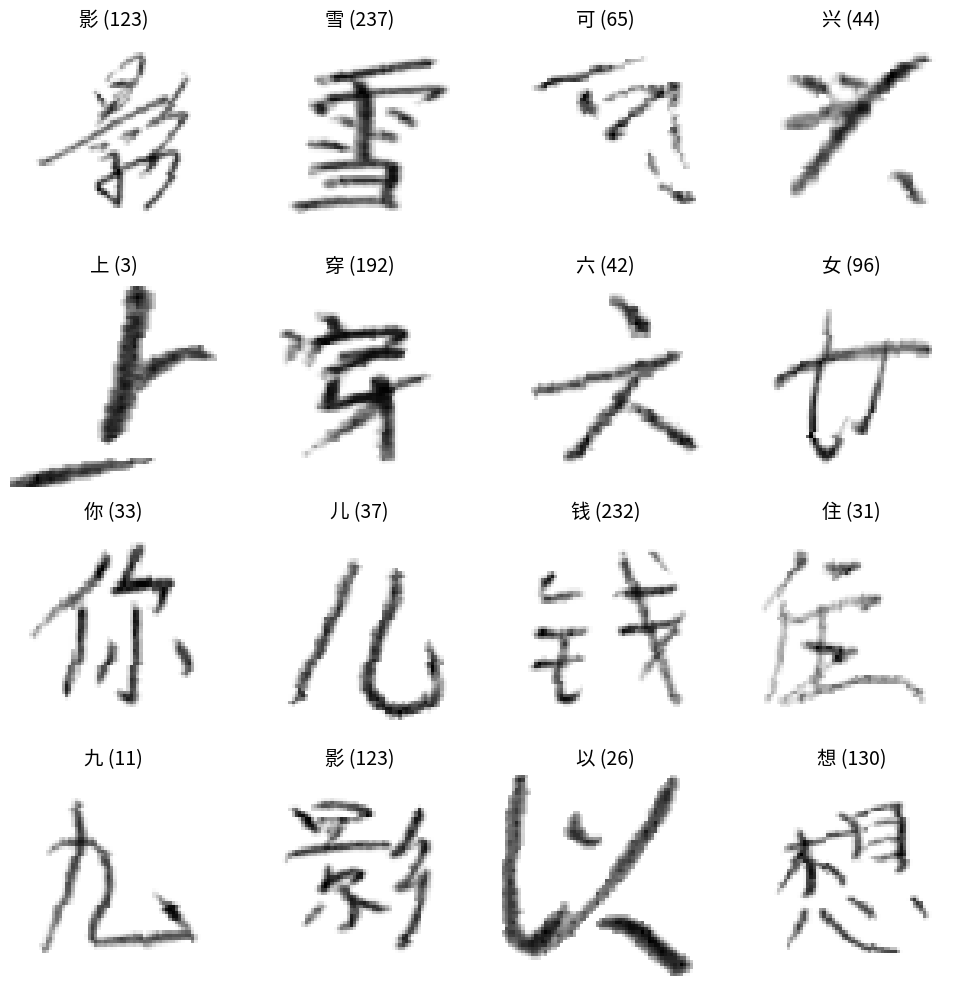

Labels in the displayed batch:
Image 1: class 123, label 影
Image 2: class 237, label 雪
Image 3: class 65, label 可
Image 4: class 44, label 兴
Image 5: class 3, label 上
Image 6: class 192, label 穿
Image 7: class 42, label 六
Image 8: class 96, label 女
Image 9: class 33, label 你
Image 10: class 37, label 儿
Image 11: class 232, label 钱
Image 12: class 31, label 住
Image 13: class 11, label 九
Image 14: class 123, label 影
Image 15: class 26, label 以
Image 16: class 130, label 想


In [14]:
idx_to_class = {
    index: class_name
    for class_name, index in train_dataset_augmented.class_to_idx.items()
}

images, labels = next(iter(fold_train_loader))

plt.figure(figsize=(10, 10))

for index in range(16):
    image = images[index].squeeze(0)

    # Convert values back to the visible range
    image = image * 0.5 + 0.5

    class_index = labels[index].item()
    label = idx_to_class[class_index]

    plt.subplot(4, 4, index + 1)
    plt.imshow(image, cmap="gray")
    plt.title(
        f"{label} ({class_index})",
        fontproperties=chinese_font,
        fontsize=14
    )
    plt.axis("off")

plt.tight_layout()
plt.show()

print("Labels in the displayed batch:")
for index in range(16):
    class_index = labels[index].item()
    label = idx_to_class[class_index]
    print(f"Image {index + 1}: class {class_index}, label {label}")


## Save Dataset Metadata


In [15]:
import json

metadata = {
    "dataset_name": "CASIA_246",
    "number_of_classes": len(train_dataset_augmented.classes),
    "training_images": len(train_dataset_augmented),
    "test_images": len(test_dataset),
    "image_size": IMAGE_SIZE,
    "batch_size": BATCH_SIZE,
    "k_folds": K_FOLDS,
    "class_to_idx": train_dataset_augmented.class_to_idx
}

METADATA_PATH = "/content/drive/MyDrive/CASIA_246_metadata.json"

with open(METADATA_PATH, "w", encoding="utf-8") as file:
    json.dump(metadata, file, ensure_ascii=False, indent=4)

print("Metadata saved to:", METADATA_PATH)


Metadata saved to: /content/drive/MyDrive/CASIA_246_metadata.json


## Save Cross-Validation Folds


In [16]:
import pickle

FOLDS_PATH = "/content/drive/MyDrive/CASIA_246_5folds.pkl"

with open(FOLDS_PATH, "wb") as file:
    pickle.dump(folds, file)

print("Cross-validation folds saved to:", FOLDS_PATH)


Cross-validation folds saved to: /content/drive/MyDrive/CASIA_246_5folds.pkl
